# Eclat

In [16]:
!pip install apyori

## Importing the libraries

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Data Preprocessing

In [18]:
dataset = pd.read_csv('Market_Basket_Optimisation.csv', header = None)
transactions = []
for i in range(0, 7501):
  transactions.append([str(dataset.values[i,j]) for j in range(0, 20)])


## Training the Eclat model on the dataset

In [19]:
from apyori import apriori
rules = apriori(transactions = transactions, min_support = 0.003, min_confidence = 0.2, min_lift = 3, min_length = 2, max_length = 2)

### Displaying the first results coming directly from the output of the apriori function

In [20]:
results = list(rules)

In [21]:
results

[RelationRecord(items=frozenset({'light cream', 'chicken'}), support=0.004532728969470737, ordered_statistics=[OrderedStatistic(items_base=frozenset({'light cream'}), items_add=frozenset({'chicken'}), confidence=0.29059829059829057, lift=4.84395061728395)]),
 RelationRecord(items=frozenset({'mushroom cream sauce', 'escalope'}), support=0.005732568990801226, ordered_statistics=[OrderedStatistic(items_base=frozenset({'mushroom cream sauce'}), items_add=frozenset({'escalope'}), confidence=0.3006993006993007, lift=3.790832696715049)]),
 RelationRecord(items=frozenset({'pasta', 'escalope'}), support=0.005865884548726837, ordered_statistics=[OrderedStatistic(items_base=frozenset({'pasta'}), items_add=frozenset({'escalope'}), confidence=0.3728813559322034, lift=4.700811850163794)]),
 RelationRecord(items=frozenset({'fromage blanc', 'honey'}), support=0.003332888948140248, ordered_statistics=[OrderedStatistic(items_base=frozenset({'fromage blanc'}), items_add=frozenset({'honey'}), confidence=0

### Putting the results well organised into a Pandas DataFrame

In [22]:
def inspect(results):
    lhs         = [tuple(result[2][0][0])[0] for result in results]
    rhs         = [tuple(result[2][0][1])[0] for result in results]
    supports    = [result[1] for result in results]
    return list(zip(lhs, rhs, supports))
resultsinDataFrame = pd.DataFrame(inspect(results), columns = ['Product 1', 'Product 2', 'Support'])

In [23]:
resultsinDataFrame

,Product 1,Product 2,Support
0,light cream,chicken,0.004533
1,mushroom cream sauce,escalope,0.005733
2,pasta,escalope,0.005866
3,fromage blanc,honey,0.003333
4,herb & pepper,ground beef,0.015998
5,tomato sauce,ground beef,0.005333
6,light cream,olive oil,0.003200
7,whole wheat pasta,olive oil,0.007999
8,pasta,shrimp,0.005066


### Displaying the results sorted by descending supports

In [24]:
resultsinDataFrame.nlargest(n = 10, columns = 'Support')

,Product 1,Product 2,Support
4,herb & pepper,ground beef,0.015998
7,whole wheat pasta,olive oil,0.007999
2,pasta,escalope,0.005866
1,mushroom cream sauce,escalope,0.005733
5,tomato sauce,ground beef,0.005333
8,pasta,shrimp,0.005066
0,light cream,chicken,0.004533
3,fromage blanc,honey,0.003333
6,light cream,olive oil,0.003200


# Visualising the result

/tmp/ipykernel_3180/92625882.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Support', y='Association', data=top_associations, palette='viridis')


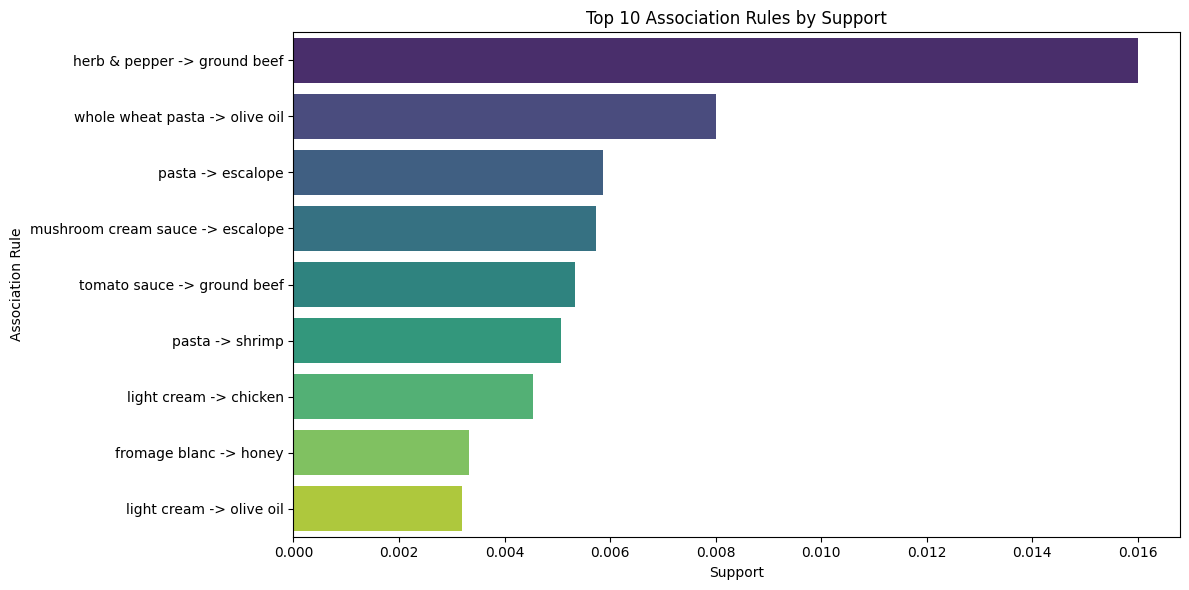

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 associations by support
top_associations = resultsinDataFrame.nlargest(n=10, columns='Support')

# Create a combined label for the plot
top_associations['Association'] = top_associations['Product 1'] + ' -> ' + top_associations['Product 2']

plt.figure(figsize=(12, 6))
sns.barplot(x='Support', y='Association', data=top_associations, palette='viridis')
plt.title('Top 10 Association Rules by Support')
plt.xlabel('Support')
plt.ylabel('Association Rule')
plt.tight_layout()
plt.show()